# 🌧️ Rainfall Prediction using Machine Learning

**Dataset:** Area Weighted Monthly, Seasonal and Annual Rainfall  
**Goal:** Predict Annual Rainfall using monthly and seasonal features  
**Model:** Linear Regression

---

## 📋 Table of Contents
1. [Import Libraries & Dataset](#step1)
2. [Exploratory Data Analysis (EDA)](#step2)
3. [Data Visualization](#step3)
4. [Data Cleaning](#step4)
5. [Data Preparation](#step5)
6. [Train-Test Split](#step6)
7. [Build Model](#step7)
8. [Model Evaluation](#step8)

---
<a id='step1'></a>
## Step 1: Import Libraries & Dataset

We begin by importing all the necessary Python libraries and loading our Excel dataset.  
The dataset contains area-weighted rainfall data with monthly, seasonal, and annual values.

In [1]:
# --- Core Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# --- Scikit-learn ---
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Settings ---
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# --- Create visualizations folder if it doesn't exist ---
os.makedirs('visualizations', exist_ok=True)

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


In [3]:
# --- Robust Excel Loading ---
# This function handles common issues in government/meteorological Excel files:
# - Metadata rows at the top
# - Merged cells
# - Extra whitespace in column names

FILE_PATH = r'F:\Downloads\Area_Weighted_Monthly_Seasonal_And_Annual_Rainfall_0.xls'

def load_rainfall_excel(filepath):
    """Robustly loads the rainfall Excel file, handling common formatting issues."""
    
    # Try loading with header=0 first (standard)
    df = pd.read_excel(filepath, header=0)
    
    # If first column looks like metadata (non-numeric, non-station name),
    # try skipping rows until a proper header is found
    for skip in range(0, 5):
        df_try = pd.read_excel(filepath, header=skip)
        # Check if 'YEAR' or 'Year' column exists after skipping rows
        cols_upper = [str(c).strip().upper() for c in df_try.columns]
        if any('YEAR' in c or 'ANNUAL' in c for c in cols_upper):
            df = df_try
            print(f'   Header found at row: {skip}')
            break
    
    # Normalize column names: strip whitespace, uppercase
    df.columns = [str(c).strip().upper().replace(' ', '_') for c in df.columns]
    
    return df


# Load the dataset
df = load_rainfall_excel(FILE_PATH)

print(f'✅ Dataset loaded successfully!')
print(f'   Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'   Columns: {list(df.columns)}')

   Header found at row: 0
✅ Dataset loaded successfully!
   Shape: 2301 rows × 20 columns
   Columns: ['SD_NO.', 'SD_NAME', 'YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC']


---
<a id='step2'></a>
## Step 2: Exploratory Data Analysis (EDA)

EDA helps us understand the structure, content, and quality of the dataset before applying any ML model.  
We check data types, summary statistics, and look for any anomalies.

In [4]:
# --- First look at the data ---
print('--- First 5 rows ---')
df.head()

--- First 5 rows ---


,SD_NO.,SD_NAME,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC
0,1,ANDAMAN & NICOBAR ISLANDS,1951,82.7,7.2,0.0,45.4,259.0,619.9,665.3,101.3,360.9,489.0,209.6,434.8,3275.1,89.9,304.4,1747.4,1133.4
1,2,ARUNACHAL PRADESH,1951,31.8,65.3,309.9,441.0,344.5,757.8,554.7,278.5,383.7,101.8,46.2,39.1,3354.3,97.1,1095.4,1974.7,187.1
2,3,ASSAM & MEGHALAYA,1951,4.5,2.9,54.6,230.0,270.6,688.4,665.9,444.4,241.5,302.2,46.3,5.4,2956.7,7.4,555.2,2040.2,353.9
3,4,"NAGALAND, MANIPUR, MIZORAM,TRIPURA",1951,3.9,0.2,62.4,360.1,233.7,495.0,436.2,440.5,191.1,310.6,54.9,20.8,2609.4,4.1,656.2,1562.8,386.3
4,5,SUB-HIMALAYAN W BENGAL & SIKKIM,1951,1.0,0.5,22.7,69.3,239.8,546.5,778.3,503.7,326.1,158.0,37.3,0.0,2683.2,1.5,331.8,2154.6,195.3


In [5]:
# --- Dataset Shape ---
print(f'Rows   : {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

Rows   : 2301
Columns: 20


In [6]:
# --- Column names & data types ---
print('--- df.info() ---')
df.info()

--- df.info() ---
<class 'pandas.DataFrame'>
RangeIndex: 2301 entries, 0 to 2300
Data columns (total 20 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   SD_NO.   2301 non-null   int64  
 1   SD_NAME  2301 non-null   str    
 2   YEAR     2301 non-null   int64  
 3   JAN      2300 non-null   float64
 4   FEB      2299 non-null   float64
 5   MAR      2300 non-null   float64
 6   APR      2301 non-null   float64
 7   MAY      2301 non-null   float64
 8   JUN      2301 non-null   float64
 9   JUL      2301 non-null   float64
 10  AUG      2300 non-null   float64
 11  SEP      2300 non-null   float64
 12  OCT      2300 non-null   float64
 13  NOV      2300 non-null   float64
 14  DEC      2300 non-null   float64
 15  ANNUAL   2296 non-null   float64
 16  JAN-FEB  2299 non-null   float64
 17  MAR-MAY  2300 non-null   float64
 18  JUN-SEP  2300 non-null   float64
 19  OCT-DEC  2299 non-null   float64
dtypes: float64(17), int64(2), str(1)
memory usage

In [7]:
# --- Statistical Summary ---
print('--- df.describe() ---')
df.describe()

--- df.describe() ---


,SD_NO.,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC
count,2301.000000,2301.000000,2300.000000,2299.000000,2300.000000,2301.000000,2301.000000,2301.000000,2301.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2296.000000,2299.000000,2300.000000,2300.000000,2299.000000
mean,18.521512,1982.535854,17.246652,20.390561,27.545609,42.096002,87.069883,225.513081,343.396045,291.862087,195.666522,98.540435,38.751652,18.721348,1401.135105,37.644411,156.450913,1056.598130,155.955241
std,10.380211,18.462256,29.906491,35.601650,47.113929,64.754779,122.115355,225.161045,266.920853,191.209987,131.301172,99.361572,66.822588,41.787278,885.887743,57.813342,197.728872,703.010519,165.613939
min,1.000000,1951.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.400000,5.600000,4.000000,0.100000,0.000000,0.000000,0.000000,86.500000,0.000000,0.000000,79.400000,0.000000
25%,10.000000,1967.000000,0.400000,0.400000,1.000000,3.200000,9.100000,71.900000,174.500000,161.700000,98.900000,16.275000,0.900000,0.100000,795.375000,2.900000,23.800000,579.525000,36.000000
50%,19.000000,1983.000000,5.100000,5.700000,7.300000,15.400000,37.100000,137.200000,278.800000,260.000000,171.600000,69.300000,9.900000,3.300000,1107.550000,15.600000,74.450000,878.800000,103.300000
75%,28.000000,1999.000000,20.300000,24.350000,30.800000,48.800000,98.300000,293.500000,410.500000,370.425000,264.325000,152.325000,45.725000,18.400000,1652.525000,45.850000,200.775000,1267.150000,215.500000
max,36.000000,2014.000000,300.800000,363.700000,353.900000,551.500000,973.100000,1432.800000,1884.900000,1664.600000,1034.800000,669.400000,583.000000,500.700000,5553.900000,545.700000,1172.300000,4537.000000,1133.400000


In [8]:
# --- Missing Values ---
print('--- Missing Values per Column ---')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found ✅')

--- Missing Values per Column ---
JAN        1
FEB        2
MAR        1
AUG        1
SEP        1
OCT        1
NOV        1
DEC        1
ANNUAL     5
JAN-FEB    2
MAR-MAY    1
JUN-SEP    1
OCT-DEC    2
dtype: int64


In [9]:
# --- Unique values in key columns ---
# Identify the YEAR column dynamically
year_col = [c for c in df.columns if 'YEAR' in c]
station_col = [c for c in df.columns if 'STATION' in c or 'SUBDIVISION' in c or 'NAME' in c]

if year_col:
    print(f'Years available ({year_col[0]}): {sorted(df[year_col[0]].dropna().unique())}')
if station_col:
    print(f'\nUnique Stations ({station_col[0]}): {df[station_col[0]].nunique()}')
    print(df[station_col[0]].unique()[:10])  # Show first 10

Years available (YEAR): [np.int64(1951), np.int64(1952), np.int64(1953), np.int64(1954), np.int64(1955), np.int64(1956), np.int64(1957), np.int64(1958), np.int64(1959), np.int64(1960), np.int64(1961), np.int64(1962), np.int64(1963), np.int64(1964), np.int64(1965), np.int64(1966), np.int64(1967), np.int64(1968), np.int64(1969), np.int64(1970), np.int64(1971), np.int64(1972), np.int64(1973), np.int64(1974), np.int64(1975), np.int64(1976), np.int64(1977), np.int64(1978), np.int64(1979), np.int64(1980), np.int64(1981), np.int64(1982), np.int64(1983), np.int64(1984), np.int64(1985), np.int64(1986), np.int64(1987), np.int64(1988), np.int64(1989), np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011),

**EDA Insights:**
- We can see the dataset contains monthly rainfall values (Jan–Dec), seasonal totals, and an Annual column.
- We'll use the monthly columns as features (X) and the ANNUAL column as the target (Y).
- Missing values and duplicates will be handled in Step 4.

---
<a id='step3'></a>
## Step 3: Data Visualization

Visualizations help us understand distributions, relationships, and trends in the data.  
All plots are saved in the `/visualizations` folder.

In [10]:
# --- Identify the ANNUAL column ---
annual_col = [c for c in df.columns if 'ANNUAL' in c]
if not annual_col:
    annual_col = [c for c in df.columns if 'ANN' in c]
annual_col = annual_col[0] if annual_col else df.select_dtypes(include=np.number).columns[-1]

print(f'Annual Rainfall Column identified as: "{annual_col}"')

Annual Rainfall Column identified as: "ANNUAL"


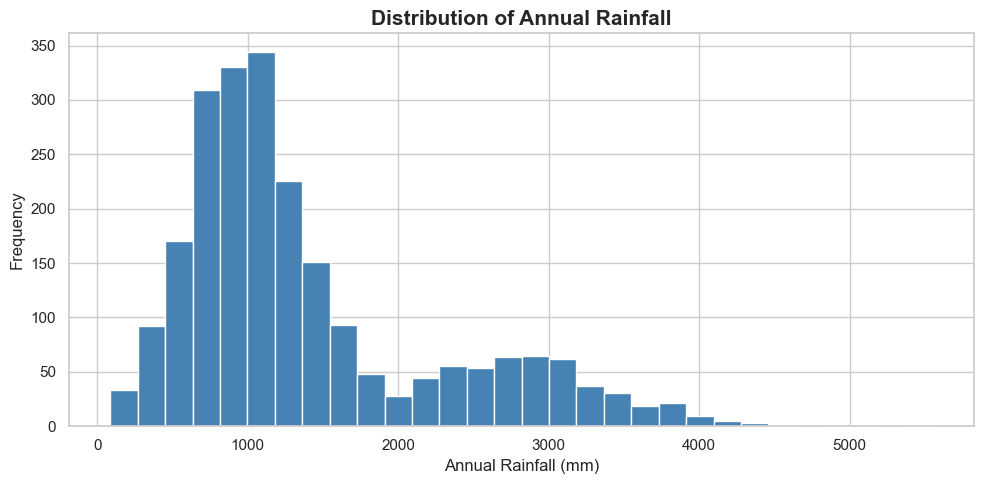

✅ Saved: visualizations/histogram.png


In [11]:
# --- Plot 1: Histogram of Annual Rainfall ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df[annual_col].dropna(), bins=30, color='steelblue', edgecolor='white')
ax.set_title('Distribution of Annual Rainfall', fontsize=15, fontweight='bold')
ax.set_xlabel('Annual Rainfall (mm)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('visualizations/histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: visualizations/histogram.png')

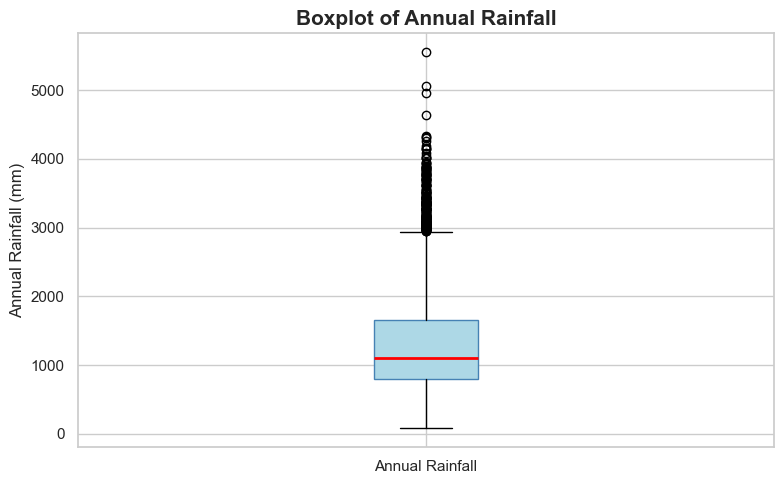

✅ Saved: visualizations/boxplot.png


In [12]:
# --- Plot 2: Boxplot of Annual Rainfall ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(df[annual_col].dropna(), patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
ax.set_title('Boxplot of Annual Rainfall', fontsize=15, fontweight='bold')
ax.set_ylabel('Annual Rainfall (mm)')
ax.set_xticks([1])
ax.set_xticklabels(['Annual Rainfall'])
plt.tight_layout()
plt.savefig('visualizations/boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: visualizations/boxplot.png')

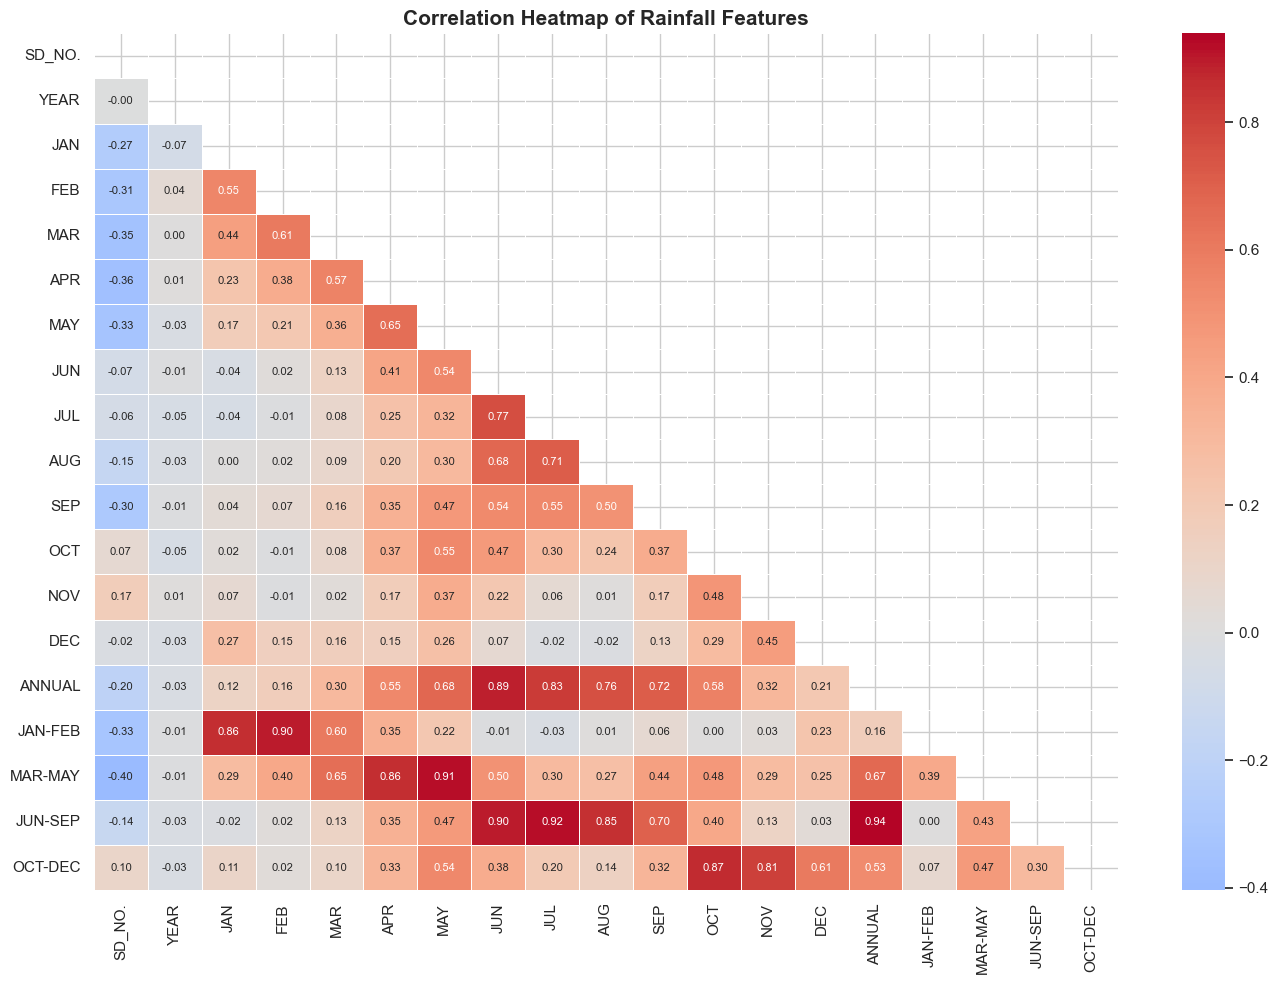

✅ Saved: visualizations/correlation_heatmap.png


In [13]:
# --- Plot 3: Correlation Heatmap ---
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=np.number)

fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show only lower triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap of Rainfall Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: visualizations/correlation_heatmap.png')

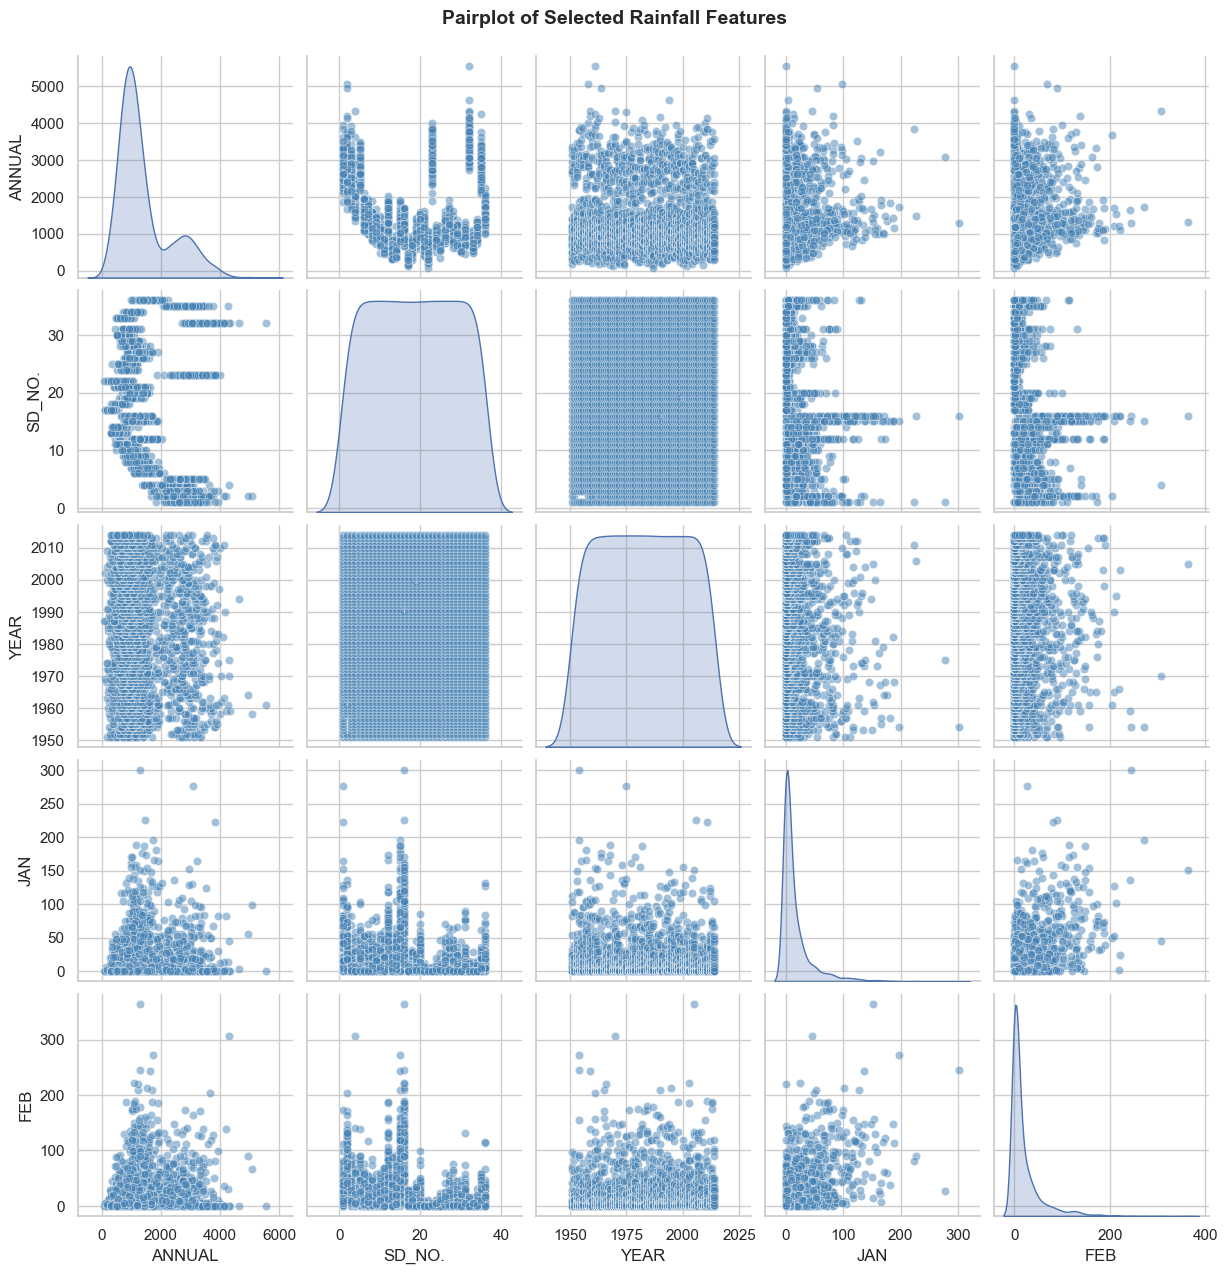

✅ Saved: visualizations/pairplot.png


In [14]:
# --- Plot 4: Pairplot (top 5 numeric columns including Annual) ---
# We limit to 5 columns to keep pairplot readable
num_cols = numeric_df.columns.tolist()
# Prioritize: include Annual col + first 4 numeric cols
pair_cols = [annual_col] + [c for c in num_cols if c != annual_col][:4]

pairplot_df = df[pair_cols].dropna()
pair_fig = sns.pairplot(pairplot_df, diag_kind='kde', plot_kws={'alpha': 0.5, 'color': 'steelblue'})
pair_fig.fig.suptitle('Pairplot of Selected Rainfall Features', y=1.02, fontsize=14, fontweight='bold')
pair_fig.savefig('visualizations/pairplot.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved: visualizations/pairplot.png')

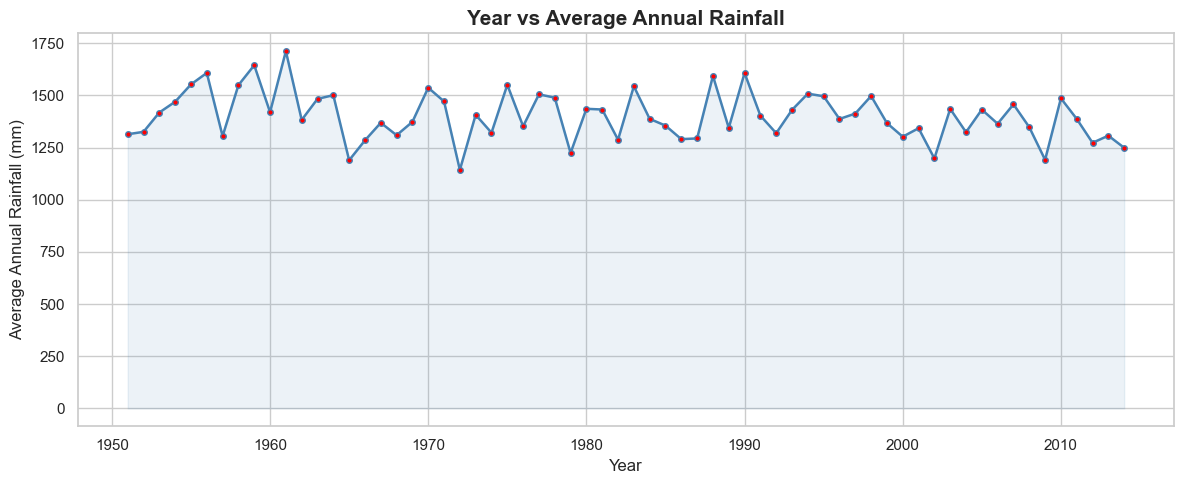

✅ Saved: visualizations/yearly_trend.png


In [15]:
# --- Plot 5: Line Plot - Year vs Annual Rainfall ---
if year_col:
    year_annual = df[[year_col[0], annual_col]].dropna()
    # Group by year (average if multiple stations)
    year_avg = year_annual.groupby(year_col[0])[annual_col].mean().reset_index()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(year_avg[year_col[0]], year_avg[annual_col],
            marker='o', markersize=4, linewidth=1.8,
            color='steelblue', markerfacecolor='red')
    ax.fill_between(year_avg[year_col[0]], year_avg[annual_col], alpha=0.1, color='steelblue')
    ax.set_title('Year vs Average Annual Rainfall', fontsize=15, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Average Annual Rainfall (mm)')
    plt.tight_layout()
    plt.savefig('visualizations/yearly_trend.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved: visualizations/yearly_trend.png')
else:
    print('⚠️ No YEAR column found — skipping yearly trend plot.')

**Visualization Insights:**
- The **histogram** shows the distribution of annual rainfall — we can see if it's skewed.
- The **boxplot** reveals outliers in annual rainfall values.
- The **heatmap** shows which monthly/seasonal columns are most correlated with annual rainfall.
- The **line plot** shows how annual rainfall has changed over the years.

---
<a id='step4'></a>
## Step 4: Data Cleaning

Real-world datasets often contain noise. We handle:
1. **Missing values** – filled with column median
2. **Duplicate rows** – removed
3. **Outliers** – removed using IQR method

In [16]:
print(f'Shape BEFORE cleaning: {df.shape}')

# --- 1. Handle Missing Values ---
# Fill numeric columns with their median (robust to outliers)
numeric_cols = df.select_dtypes(include=np.number).columns
missing_before = df[numeric_cols].isnull().sum().sum()

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'   Filled missing values in "{col}" with median: {median_val:.2f}')

print(f'\n✅ Missing values handled. Total filled: {missing_before}')

Shape BEFORE cleaning: (2301, 20)
   Filled missing values in "JAN" with median: 5.10
   Filled missing values in "FEB" with median: 5.70
   Filled missing values in "MAR" with median: 7.30
   Filled missing values in "AUG" with median: 260.00
   Filled missing values in "SEP" with median: 171.60
   Filled missing values in "OCT" with median: 69.30
   Filled missing values in "NOV" with median: 9.90
   Filled missing values in "DEC" with median: 3.30
   Filled missing values in "ANNUAL" with median: 1107.55
   Filled missing values in "JAN-FEB" with median: 15.60
   Filled missing values in "MAR-MAY" with median: 74.45
   Filled missing values in "JUN-SEP" with median: 878.80
   Filled missing values in "OCT-DEC" with median: 103.30

✅ Missing values handled. Total filled: 20


In [17]:
# --- 2. Remove Duplicate Rows ---
duplicates = df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'✅ Duplicate rows removed: {duplicates}')

✅ Duplicate rows removed: 0


In [18]:
# --- 3. Handle Outliers using IQR Method on Annual Rainfall ---
# IQR = Interquartile Range (Q3 - Q1)
# Outliers are values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR

Q1 = df[annual_col].quantile(0.25)
Q3 = df[annual_col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_count = df[(df[annual_col] < lower_bound) | (df[annual_col] > upper_bound)].shape[0]

# Remove outliers
df = df[(df[annual_col] >= lower_bound) & (df[annual_col] <= upper_bound)]
df.reset_index(drop=True, inplace=True)

print(f'IQR Method: Lower Bound = {lower_bound:.2f}, Upper Bound = {upper_bound:.2f}')
print(f'✅ Outliers removed: {outliers_count}')
print(f'\nShape AFTER cleaning: {df.shape}')

IQR Method: Lower Bound = -490.35, Upper Bound = 2938.25
✅ Outliers removed: 209

Shape AFTER cleaning: (2087, 20)


---
<a id='step5'></a>
## Step 5: Data Preparation

We now prepare the data for modeling:
- **Drop non-numeric columns** (e.g., Station Name) as they can't be used by the model directly
- **Define X (features)** → all monthly/seasonal columns
- **Define Y (target)** → ANNUAL rainfall
- **Apply StandardScaler** to normalize feature values

In [19]:
# --- Drop non-numeric / identifier columns ---
# Keep only numeric columns for modeling
df_model = df.select_dtypes(include=np.number).copy()

# Also drop YEAR column if present (it's an identifier, not a feature)
cols_to_drop = [c for c in df_model.columns if 'YEAR' in c]
df_model.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(f'Columns used for modeling: {list(df_model.columns)}')

Columns used for modeling: ['SD_NO.', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC']


In [20]:
# --- Define Features (X) and Target (Y) ---
# Target: Annual Rainfall column
# Features: All other numeric columns

Y = df_model[annual_col]                                    # Target variable
X = df_model.drop(columns=[annual_col])                     # Feature variables

print(f'Target (Y): "{annual_col}"  → shape: {Y.shape}')
print(f'Features (X): {list(X.columns)}  → shape: {X.shape}')

Target (Y): "ANNUAL"  → shape: (2087,)
Features (X): ['SD_NO.', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC']  → shape: (2087, 17)


In [21]:
# --- Feature Scaling using StandardScaler ---
# StandardScaler transforms data to have mean=0 and std=1
# This ensures all features are on the same scale

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print('✅ Feature scaling applied (StandardScaler)')
print(f'   Mean after scaling (sample): {X_scaled.mean().values[:3].round(4)}')
print(f'   Std  after scaling (sample): {X_scaled.std().values[:3].round(4)}')

✅ Feature scaling applied (StandardScaler)
   Mean after scaling (sample): [ 0. -0.  0.]
   Std  after scaling (sample): [1.0002 1.0002 1.0002]


---
<a id='step6'></a>
## Step 6: Train-Test Split

We split the data:
- **80%** for Training — the model learns from this
- **20%** for Testing — we evaluate on unseen data

`random_state=42` ensures reproducibility (same split every time).

In [22]:
# --- Train-Test Split (80% train / 20% test) ---
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y, test_size=0.2, random_state=42
)

print(f'Total samples  : {len(X_scaled)}')
print(f'Training set   : {X_train.shape[0]} samples ({X_train.shape[0]/len(X_scaled)*100:.0f}%)')
print(f'Testing set    : {X_test.shape[0]} samples  ({X_test.shape[0]/len(X_scaled)*100:.0f}%)')

Total samples  : 2087
Training set   : 1669 samples (80%)
Testing set    : 418 samples  (20%)


---
<a id='step7'></a>
## Step 7: Build the Model

We use **Linear Regression** — a simple yet powerful algorithm for continuous target prediction.  
It finds the best-fit line: `Y = b0 + b1*X1 + b2*X2 + ...`

In [23]:
# --- Initialize and Train the Linear Regression Model ---
model = LinearRegression()
model.fit(X_train, Y_train)

print('✅ Model trained successfully!')
print(f'\nIntercept (b0): {model.intercept_:.4f}')

✅ Model trained successfully!

Intercept (b0): 1199.1279


In [24]:
# --- Show Feature Coefficients ---
# Positive coefficient = that feature increases annual rainfall prediction
# Negative coefficient = that feature decreases it

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

print('--- Model Coefficients ---')
print(coef_df.to_string(index=False))

--- Model Coefficients ---
Feature  Coefficient
JUN-SEP 12486.068393
JAN-FEB  3194.082667
OCT-DEC  1589.113474
MAR-MAY   123.967987
    MAY    26.306315
    APR    19.132313
    MAR    12.668434
 SD_NO.     2.954158
    DEC  -349.774826
    NOV  -587.400232
    OCT  -906.040699
    JAN -1613.138018
    FEB -1925.864712
    SEP -2749.779533
    AUG -3477.630717
    JUN -4131.333937
    JUL -4504.668783


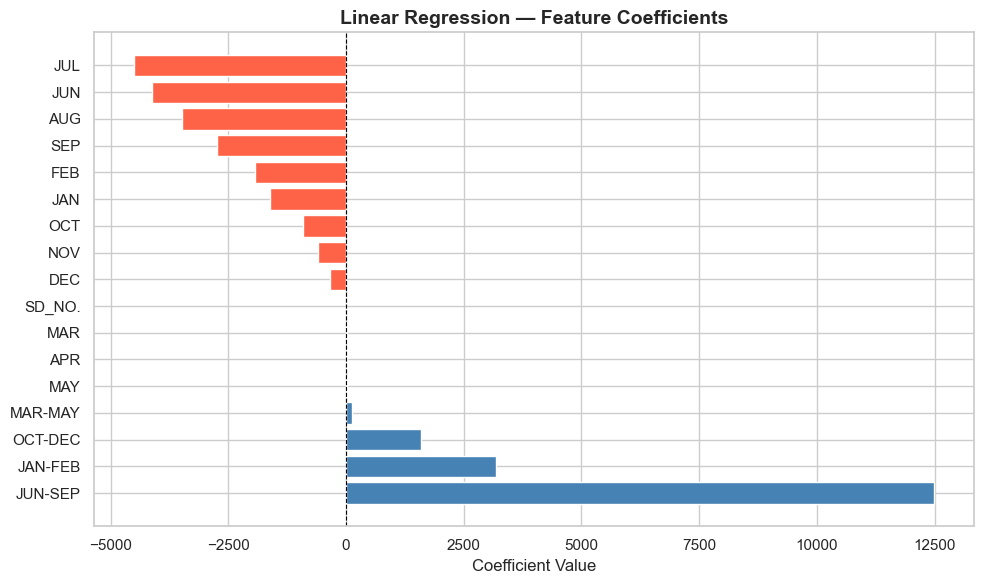

✅ Saved: visualizations/feature_coefficients.png


In [25]:
# --- Visualize Coefficients ---
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if c >= 0 else 'tomato' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Linear Regression — Feature Coefficients', fontsize=14, fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('visualizations/feature_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: visualizations/feature_coefficients.png')

---
<a id='step8'></a>
## Step 8: Model Evaluation

We evaluate the model using standard regression metrics:

| Metric | Description |
|--------|-------------|
| **MAE** | Mean Absolute Error — average absolute difference |
| **MSE** | Mean Squared Error — penalizes large errors more |
| **RMSE** | Root MSE — in same unit as rainfall (mm) |
| **R² Score** | How well the model explains variance (1.0 = perfect) |

In [26]:
# --- Make Predictions ---
Y_pred = model.predict(X_test)

# --- Calculate Metrics ---
mae  = mean_absolute_error(Y_test, Y_pred)
mse  = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(Y_test, Y_pred)

# --- Display Results ---
print('=' * 40)
print('       MODEL EVALUATION RESULTS')
print('=' * 40)
print(f'  MAE   (Mean Absolute Error)  : {mae:.4f}')
print(f'  MSE   (Mean Squared Error)   : {mse:.4f}')
print(f'  RMSE  (Root Mean Sq. Error)  : {rmse:.4f}')
print(f'  R²    (R-Squared Score)      : {r2:.4f}')
print('=' * 40)

if r2 >= 0.75:
    print('\n✅ Good model performance! R² ≥ 0.75')
elif r2 >= 0.5:
    print('\n⚠️ Moderate model performance. R² between 0.5 and 0.75')
else:
    print('\n❌ Low R² — model may need more features or different algorithm.')

       MODEL EVALUATION RESULTS
  MAE   (Mean Absolute Error)  : 6.1355
  MSE   (Mean Squared Error)   : 121.2533
  RMSE  (Root Mean Sq. Error)  : 11.0115
  R²    (R-Squared Score)      : 0.9997

✅ Good model performance! R² ≥ 0.75


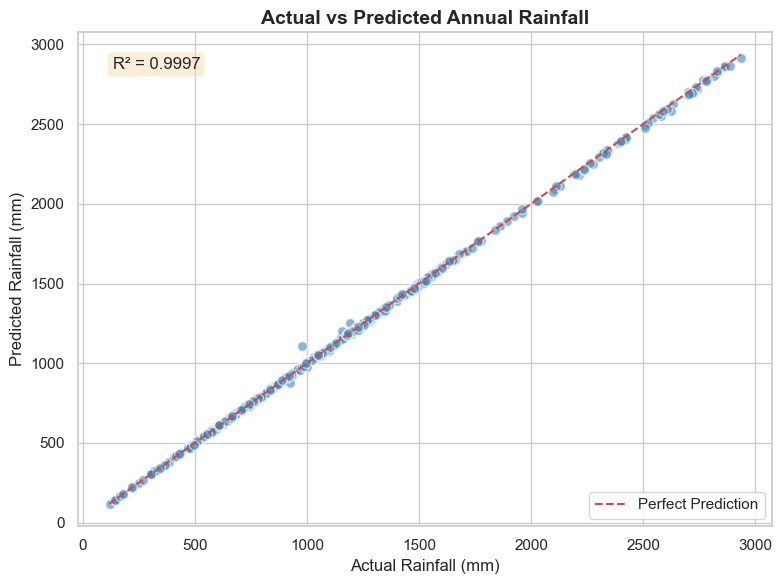

✅ Saved: visualizations/actual_vs_predicted.png


In [27]:
# --- Actual vs Predicted Plot ---
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(Y_test, Y_pred, alpha=0.6, color='steelblue', edgecolors='white', s=50)

# Perfect prediction line
min_val = min(Y_test.min(), Y_pred.min())
max_val = max(Y_test.max(), Y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')

ax.set_title('Actual vs Predicted Annual Rainfall', fontsize=14, fontweight='bold')
ax.set_xlabel('Actual Rainfall (mm)')
ax.set_ylabel('Predicted Rainfall (mm)')
ax.legend()
ax.text(0.05, 0.95, f'R² = {r2:.4f}', transform=ax.transAxes,
        fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.savefig('visualizations/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: visualizations/actual_vs_predicted.png')

---
## ✅ Project Summary

We successfully built a complete Machine Learning pipeline:

1. **Loaded** the rainfall Excel dataset with robust handling
2. **Explored** the data using EDA (shape, types, missing values)
3. **Visualized** distributions, correlations, and yearly trends
4. **Cleaned** the data (missing values → median fill, duplicates removed, outliers via IQR)
5. **Prepared** features (X) and target (Y = Annual Rainfall), applied StandardScaler
6. **Split** data 80/20 for training and testing
7. **Trained** a Linear Regression model and examined coefficients
8. **Evaluated** using MAE, MSE, RMSE, and R² Score

All visualizations saved in the `/visualizations` folder. 🎉